# Notebook 3 — Baseline Model Training

**Goal:** Establish a performance baseline by training five models on the Jan 2023 processed dataset and selecting the best one for the serving pipeline.

**Models trained:**
| # | Model | Purpose |
|---|---|---|
| 1 | `DummyRegressor` (mean) | Absolute lower bound |
| 2 | `LinearRegression` (scaled) | Linear baseline |
| 3 | `RandomForestRegressor` | Non-linear ensemble baseline |
| 4 | `XGBRegressor` — raw target | Gradient boosting on minutes |
| 5 | `XGBRegressor` — log1p target | Gradient boosting on log-minutes (config: `log_transform_target: true`) |
| 6 | `LGBMRegressor` | LightGBM baseline |

**Split strategy:** Time-based — last 7 days of January held out as validation (per `config.yaml: training.val_days: 7`).

**Tracking:** All runs logged to MLflow (`experiment: nyc-taxi-duration`).

**Output:** Best model + metadata saved to `models/`.

---
## Section 1 — Imports & Configuration

In [20]:
import os
import json
import logging
import warnings
import pickle
from pathlib import Path
from datetime import timedelta

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

import mlflow
import mlflow.sklearn
import mlflow.xgboost
import mlflow.lightgbm

warnings.filterwarnings('ignore')
logging.getLogger('mlflow.sklearn').setLevel(logging.ERROR)
logging.getLogger('mlflow.lightgbm').setLevel(logging.ERROR)
pd.set_option('display.float_format', '{:.4f}'.format)

print('All imports OK')

All imports OK


In [21]:
# ── Paths ──────────────────────────────────────────────────────────────────
NOTEBOOK_DIR  = Path().resolve()
PROJECT_ROOT  = NOTEBOOK_DIR.parent
CONFIG_PATH   = PROJECT_ROOT / 'configs' / 'config.yaml'

with open(CONFIG_PATH) as f:
    cfg = yaml.safe_load(f)

YEAR  = cfg['data']['year']
MONTH = cfg['data']['month']

PROCESSED_PATH = PROJECT_ROOT / cfg['data']['paths']['processed'].format(year=YEAR, month=MONTH)
MODELS_DIR     = PROJECT_ROOT / cfg['data']['paths']['models']
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# ── Training config ─────────────────────────────────────────────────────────
RANDOM_STATE        = cfg['training']['random_state']
VAL_DAYS            = cfg['training']['val_days']
LOG_TRANSFORM       = cfg['training']['log_transform_target']
TARGET              = cfg['features']['target']
NUMERIC_FEATURES    = cfg['features']['numeric']
CATEGORICAL_FEATURES= cfg['features']['categorical']

# ── MLflow ──────────────────────────────────────────────────────────────────
MLFLOW_TRACKING_URI = f"sqlite:///{PROJECT_ROOT / cfg['mlflow']['tracking_uri']}"
EXPERIMENT_NAME     = cfg['mlflow']['experiment_name']

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(EXPERIMENT_NAME)

print(f'Config loaded  : {CONFIG_PATH}')
print(f'Processed data : {PROCESSED_PATH}')
print(f'Models dir     : {MODELS_DIR}')
print(f'MLflow URI     : {MLFLOW_TRACKING_URI}')
print(f'Val days       : {VAL_DAYS}  |  log-transform: {LOG_TRANSFORM}')

Config loaded  : /Users/adityaboghara/Desktop/NYC End to End Project /nyc-taxi-duration-prediction-self-healing-ml/configs/config.yaml
Processed data : /Users/adityaboghara/Desktop/NYC End to End Project /nyc-taxi-duration-prediction-self-healing-ml/data/processed/processed_rides_2023-01.parquet
Models dir     : /Users/adityaboghara/Desktop/NYC End to End Project /nyc-taxi-duration-prediction-self-healing-ml/models
MLflow URI     : sqlite:////Users/adityaboghara/Desktop/NYC End to End Project /nyc-taxi-duration-prediction-self-healing-ml/mlflow.db
Val days       : 7  |  log-transform: True


---
## Section 2 — Load Processed Dataset

In [22]:
df = pd.read_parquet(PROCESSED_PATH)

# Ensure datetime column is present for time-based split
# (pickup_datetime is preserved in the processed parquet)
if 'tpep_pickup_datetime' in df.columns:
    df = df.rename(columns={'tpep_pickup_datetime': 'pickup_datetime'})

print(f'Shape          : {df.shape}')
print(f'Date range     : {df["pickup_datetime"].min()}  →  {df["pickup_datetime"].max()}')
print(f'Target (min)   : mean={df[TARGET].mean():.2f}  median={df[TARGET].median():.2f}  std={df[TARGET].std():.2f}')
print(f'\nColumns:')
print(df.columns.tolist())

Shape          : (2883614, 14)
Date range     : 2023-01-01 00:00:05  →  2023-01-31 23:59:59
Target (min)   : mean=14.45  median=11.52  std=10.81

Columns:
['pickup_datetime', 'PULocationID', 'DOLocationID', 'trip_distance', 'passenger_count', 'RatecodeID', 'hour', 'dayofweek', 'is_weekend', 'is_rush_hour', 'PU_borough_id', 'DO_borough_id', 'is_airport_trip', 'trip_duration_min']


In [23]:
# ── Resolve feature columns that actually exist in the dataset ──────────────
available_features = [c for c in NUMERIC_FEATURES + CATEGORICAL_FEATURES if c in df.columns]
missing_features   = [c for c in NUMERIC_FEATURES + CATEGORICAL_FEATURES if c not in df.columns]

if missing_features:
    print(f'[WARN] Features in config but absent from data (skipped): {missing_features}')

print(f'Features used ({len(available_features)}): {available_features}')
print(f'Target: {TARGET}')

Features used (12): ['trip_distance', 'passenger_count', 'hour', 'dayofweek', 'PU_borough_id', 'DO_borough_id', 'PULocationID', 'DOLocationID', 'RatecodeID', 'is_weekend', 'is_rush_hour', 'is_airport_trip']
Target: trip_duration_min


---
## Section 3 — Feature Matrix & Time-Based Train / Val Split

**Why time-based?** Random splits leak future data into training, inflating validation metrics. Holding out the last `val_days` days simulates real deployment conditions where the model is evaluated on unseen future trips.

In [24]:
# ── Time-based split ─────────────────────────────────────────────────────────
df_sorted    = df.sort_values('pickup_datetime').reset_index(drop=True)
test_cutoff  = df_sorted['pickup_datetime'].max() - timedelta(days=VAL_DAYS)   # Jan 24
val_cutoff   = test_cutoff - timedelta(days=VAL_DAYS)                          # Jan 17

train_mask = df_sorted['pickup_datetime'] <= val_cutoff
val_mask   = (df_sorted['pickup_datetime'] > val_cutoff) & (df_sorted['pickup_datetime'] <= test_cutoff)
test_mask  = df_sorted['pickup_datetime'] > test_cutoff

train_df = df_sorted[train_mask]
val_df   = df_sorted[val_mask]
test_df  = df_sorted[test_mask]

X_train = train_df[available_features]
y_train = train_df[TARGET]
X_val   = val_df[available_features]
y_val   = val_df[TARGET]
X_test  = test_df[available_features]
y_test  = test_df[TARGET]

print(f'Val cutoff     : {val_cutoff.date()}')
print(f'Test cutoff    : {test_cutoff.date()}')
print(f'Train rows     : {len(X_train):,}  ({len(X_train)/len(df)*100:.1f}%)  Jan 1  – Jan 17')
print(f'Val rows       : {len(X_val):,}  ({len(X_val)/len(df)*100:.1f}%)  Jan 18 – Jan 24')
print(f'Test rows      : {len(X_test):,}  ({len(X_test)/len(df)*100:.1f}%)  Jan 25 – Jan 31')
print(f'\nTrain target stats: mean={y_train.mean():.2f}  median={y_train.median():.2f}')
print(f'Val   target stats: mean={y_val.mean():.2f}  median={y_val.median():.2f}')
print(f'Test  target stats: mean={y_test.mean():.2f}  median={y_test.median():.2f}')

Val cutoff     : 2023-01-17
Test cutoff    : 2023-01-24
Train rows     : 1,524,201  (52.9%)  Jan 1  – Jan 17
Val rows       : 683,024  (23.7%)  Jan 18 – Jan 24
Test rows      : 676,389  (23.5%)  Jan 25 – Jan 31

Train target stats: mean=14.41  median=11.45
Val   target stats: mean=14.46  median=11.53
Test  target stats: mean=14.54  median=11.67


In [25]:
# Log-transformed targets for XGBoost log-variant
y_train_log = np.log1p(y_train)
y_val_log   = np.log1p(y_val)
y_test_log  = np.log1p(y_test)

print(f'y_train range: [{y_train.min():.2f}, {y_train.max():.2f}] min')
print(f'y_train_log range: [{y_train_log.min():.3f}, {y_train_log.max():.3f}]')

y_train range: [1.00, 119.80] min
y_train_log range: [0.693, 4.794]


---
## Section 4 — Evaluation Helper

In [26]:
def evaluate(y_true: pd.Series, y_pred: np.ndarray, label: str = '') -> dict:
    """Return MAE, RMSE, R² on raw (minute) scale."""
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    if label:
        print(f'{label:<40}  MAE={mae:.3f}  RMSE={rmse:.3f}  R²={r2:.4f}')
    return {'mae': mae, 'rmse': rmse, 'r2': r2}


val_results  = {}   # model_name → val metrics (used for model selection)
test_results = {}   # model_name → test metrics (final evaluation)
trained_models = {} # model_name → fitted estimator

print('Evaluation helper ready.')

Evaluation helper ready.


---
## Section 5 — Model 1: DummyRegressor (Mean Predictor)

**Purpose:** Sets the absolute performance floor. Any real model must beat this to be worth deploying.

In [27]:
with mlflow.start_run(run_name='dummy_mean'):
    dummy = DummyRegressor(strategy='mean')
    dummy.fit(X_train, y_train)

    val_metrics  = evaluate(y_val,  dummy.predict(X_val),  'DummyRegressor (val)')
    test_metrics = evaluate(y_test, dummy.predict(X_test), 'DummyRegressor (test)')

    mlflow.log_params({'strategy': 'mean'})
    mlflow.log_metrics({f'val_{k}':  v for k, v in val_metrics.items()})
    mlflow.log_metrics({f'test_{k}': v for k, v in test_metrics.items()})
    mlflow.sklearn.log_model(dummy, name='model')

val_results['dummy_mean']  = val_metrics
test_results['dummy_mean'] = test_metrics
trained_models['dummy_mean'] = dummy

DummyRegressor (val)                      MAE=7.688  RMSE=10.844  R²=-0.0000
DummyRegressor (test)                     MAE=7.678  RMSE=10.752  R²=-0.0001


---
## Section 6 — Model 2: Linear Regression (Scaled)

**Why scale?** `PULocationID`/`DOLocationID` have values up to 265 while `is_weekend` is 0/1. Without scaling, linear model coefficients are on incomparable scales, making the result unreliable.

In [28]:
with mlflow.start_run(run_name='linear_regression_scaled'):
    lr_pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model',  LinearRegression())
    ])
    lr_pipe.fit(X_train, y_train)

    y_pred_val_lr  = np.clip(lr_pipe.predict(X_val),  1, 120)
    y_pred_test_lr = np.clip(lr_pipe.predict(X_test), 1, 120)

    val_metrics  = evaluate(y_val,  y_pred_val_lr,  'LinearRegression (val)')
    test_metrics = evaluate(y_test, y_pred_test_lr, 'LinearRegression (test)')

    mlflow.log_params({'scaler': 'StandardScaler', 'model': 'LinearRegression'})
    mlflow.log_metrics({f'val_{k}':  v for k, v in val_metrics.items()})
    mlflow.log_metrics({f'test_{k}': v for k, v in test_metrics.items()})
    mlflow.sklearn.log_model(lr_pipe, name='model')

val_results['linear_regression']  = val_metrics
test_results['linear_regression'] = test_metrics
trained_models['linear_regression'] = lr_pipe

LinearRegression (val)                    MAE=4.176  RMSE=6.043  R²=0.6894
LinearRegression (test)                   MAE=4.288  RMSE=6.241  R²=0.6630


---
## Section 7 — Model 3: Random Forest

Hyperparameters from `config.yaml: training.models.random_forest`.

In [29]:
rf_params = cfg['training']['models']['random_forest']
print('RF hyperparams:', rf_params)

with mlflow.start_run(run_name='random_forest'):
    rf = RandomForestRegressor(**rf_params)
    rf.fit(X_train, y_train)

    val_metrics  = evaluate(y_val,  rf.predict(X_val),  'RandomForestRegressor (val)')
    test_metrics = evaluate(y_test, rf.predict(X_test), 'RandomForestRegressor (test)')

    mlflow.log_params(rf_params)
    mlflow.log_metrics({f'val_{k}':  v for k, v in val_metrics.items()})
    mlflow.log_metrics({f'test_{k}': v for k, v in test_metrics.items()})
    mlflow.sklearn.log_model(rf, name='model')

    fi = pd.Series(rf.feature_importances_, index=available_features).sort_values(ascending=False)
    print('\nTop-10 feature importances:')
    print(fi.head(10).to_string())

val_results['random_forest']  = val_metrics
test_results['random_forest'] = test_metrics
trained_models['random_forest'] = rf

RF hyperparams: {'n_estimators': 200, 'max_depth': 12, 'min_samples_leaf': 10, 'n_jobs': -1, 'random_state': 42}
RandomForestRegressor (val)               MAE=2.882  RMSE=4.524  R²=0.8259
RandomForestRegressor (test)              MAE=2.992  RMSE=4.743  R²=0.8054

Top-10 feature importances:
trip_distance     0.8915
hour              0.0560
dayofweek         0.0144
DOLocationID      0.0077
is_weekend        0.0065
DO_borough_id     0.0063
RatecodeID        0.0055
is_airport_trip   0.0053
PU_borough_id     0.0034
PULocationID      0.0023


---
## Section 8 — Model 4: XGBoost (raw target)

Hyperparameters from `config.yaml: training.models.xgboost`.

In [30]:
xgb_params = cfg['training']['models']['xgboost'].copy()
xgb_eval_metric = xgb_params.pop('eval_metric', 'mae')
print('XGB hyperparams:', xgb_params)

with mlflow.start_run(run_name='xgboost_raw_target'):
    xgb = XGBRegressor(
        **xgb_params,
        eval_metric=xgb_eval_metric,
        early_stopping_rounds=50,
        verbosity=0
    )
    xgb.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

    val_metrics  = evaluate(y_val,  xgb.predict(X_val),  'XGBRegressor raw (val)')
    test_metrics = evaluate(y_test, xgb.predict(X_test), 'XGBRegressor raw (test)')

    mlflow.log_params({**xgb_params, 'target_transform': 'none'})
    mlflow.log_metrics({f'val_{k}':  v for k, v in val_metrics.items()})
    mlflow.log_metrics({f'test_{k}': v for k, v in test_metrics.items()})
    mlflow.log_metric('best_iteration', xgb.best_iteration)
    mlflow.xgboost.log_model(xgb, name='model')
    print(f'\nBest iteration: {xgb.best_iteration}')

val_results['xgboost_raw']  = val_metrics
test_results['xgboost_raw'] = test_metrics
trained_models['xgboost_raw'] = xgb

XGB hyperparams: {'n_estimators': 500, 'max_depth': 8, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_alpha': 0.1, 'reg_lambda': 1.0, 'n_jobs': -1, 'random_state': 42}
XGBRegressor raw (val)                    MAE=2.546  RMSE=4.055  R²=0.8601
XGBRegressor raw (test)                   MAE=2.653  RMSE=4.290  R²=0.8408


2026/05/01 03:06:12 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: /var/folders/9t/d8pkv2xd6bv7cgkwpbl6w3sc0000gn/T/tmpkz70__m6/model, flavor: xgboost). Fall back to return ['xgboost==2.1.4']. Set logging level to DEBUG to see the full traceback. 



Best iteration: 499


---
## Section 9 — Model 5: XGBoost (log1p target)

**Rationale:** Trip duration is right-skewed even after outlier removal. Training on `log1p(minutes)` makes the residual distribution more symmetric, which helps gradient boosting converge to lower RMSE.

Predictions are back-transformed with `expm1()` so metrics remain in minutes for comparison.

In [31]:
with mlflow.start_run(run_name='xgboost_log_target'):
    xgb_log = XGBRegressor(
        **xgb_params,
        eval_metric=xgb_eval_metric,
        early_stopping_rounds=50,
        verbosity=0
    )
    xgb_log.fit(X_train, y_train_log, eval_set=[(X_val, y_val_log)], verbose=False)

    val_metrics  = evaluate(y_val,  np.expm1(xgb_log.predict(X_val)),  'XGBRegressor log (val)')
    test_metrics = evaluate(y_test, np.expm1(xgb_log.predict(X_test)), 'XGBRegressor log (test)')

    mlflow.log_params({**xgb_params, 'target_transform': 'log1p'})
    mlflow.log_metrics({f'val_{k}':  v for k, v in val_metrics.items()})
    mlflow.log_metrics({f'test_{k}': v for k, v in test_metrics.items()})
    mlflow.log_metric('best_iteration', xgb_log.best_iteration)
    mlflow.xgboost.log_model(xgb_log, name='model')
    print(f'\nBest iteration: {xgb_log.best_iteration}')

val_results['xgboost_log']  = val_metrics
test_results['xgboost_log'] = test_metrics
trained_models['xgboost_log'] = xgb_log

XGBRegressor log (val)                    MAE=2.551  RMSE=4.161  R²=0.8528
XGBRegressor log (test)                   MAE=2.667  RMSE=4.393  R²=0.8331


2026/05/01 03:06:47 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: /var/folders/9t/d8pkv2xd6bv7cgkwpbl6w3sc0000gn/T/tmp_4a5edp3/model, flavor: xgboost). Fall back to return ['xgboost==2.1.4']. Set logging level to DEBUG to see the full traceback. 



Best iteration: 499


---
## Section 10 — Model 6: LightGBM

Hyperparameters from `config.yaml: training.models.lightgbm`.

In [32]:
import lightgbm as lgb

lgbm_params = cfg['training']['models']['lightgbm'].copy()
print('LGBM hyperparams:', lgbm_params)

with mlflow.start_run(run_name='lightgbm'):
    lgbm_model = LGBMRegressor(**lgbm_params)
    lgbm_model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[
            lgb.early_stopping(stopping_rounds=50, verbose=False),
            lgb.log_evaluation(period=-1),
        ]
    )

    val_metrics  = evaluate(y_val,  lgbm_model.predict(X_val),  'LGBMRegressor (val)')
    test_metrics = evaluate(y_test, lgbm_model.predict(X_test), 'LGBMRegressor (test)')

    mlflow.log_params(lgbm_params)
    mlflow.log_metrics({f'val_{k}':  v for k, v in val_metrics.items()})
    mlflow.log_metrics({f'test_{k}': v for k, v in test_metrics.items()})
    mlflow.lightgbm.log_model(lgbm_model, name='model')

val_results['lightgbm']  = val_metrics
test_results['lightgbm'] = test_metrics
trained_models['lightgbm'] = lgbm_model

LGBM hyperparams: {'n_estimators': 500, 'max_depth': 8, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_alpha': 0.1, 'reg_lambda': 1.0, 'n_jobs': -1, 'random_state': 42, 'verbose': -1}
LGBMRegressor (val)                       MAE=2.660  RMSE=4.195  R²=0.8504
LGBMRegressor (test)                      MAE=2.770  RMSE=4.427  R²=0.8304


---
## Section 11 — Results Comparison

In [33]:
def make_results_df(results_dict, label):
    return (
        pd.DataFrame(results_dict)
        .T.rename_axis('model').reset_index()
        .assign(split=label)
        .sort_values('mae')
    )

val_df_results  = make_results_df(val_results,  'val')
test_df_results = make_results_df(test_results, 'test')

# Best model is chosen by lowest val MAE
best_model_name = val_df_results.iloc[0]['model']

# Add improvement vs dummy baseline
for df_r, baseline_key in [(val_df_results, 'dummy_mean'), (test_df_results, 'dummy_mean')]:
    baseline_mae = df_r.loc[df_r['model'] == baseline_key, 'mae'].values[0]
    df_r['mae_vs_dummy'] = ((df_r['mae'] - baseline_mae) / baseline_mae * 100).round(1)

print('=== Validation metrics (used for model selection) ===')
print(val_df_results[['model', 'mae', 'rmse', 'r2', 'mae_vs_dummy']].to_string(index=False))

print('\n=== Test metrics (final evaluation — never seen during training) ===')
print(test_df_results[['model', 'mae', 'rmse', 'r2', 'mae_vs_dummy']].to_string(index=False))

print(f'\nBest model (by val MAE): {best_model_name}')

=== Validation metrics (used for model selection) ===
            model    mae    rmse      r2  mae_vs_dummy
      xgboost_raw 2.5457  4.0552  0.8601      -66.9000
      xgboost_log 2.5512  4.1605  0.8528      -66.8000
         lightgbm 2.6596  4.1946  0.8504      -65.4000
    random_forest 2.8822  4.5243  0.8259      -62.5000
linear_regression 4.1761  6.0435  0.6894      -45.7000
       dummy_mean 7.6877 10.8435 -0.0000        0.0000

=== Test metrics (final evaluation — never seen during training) ===
            model    mae    rmse      r2  mae_vs_dummy
      xgboost_raw 2.6532  4.2901  0.8408      -65.4000
      xgboost_log 2.6666  4.3930  0.8331      -65.3000
         lightgbm 2.7699  4.4273  0.8304      -63.9000
    random_forest 2.9920  4.7427  0.8054      -61.0000
linear_regression 4.2881  6.2409  0.6630      -44.2000
       dummy_mean 7.6782 10.7522 -0.0001        0.0000

Best model (by val MAE): xgboost_raw


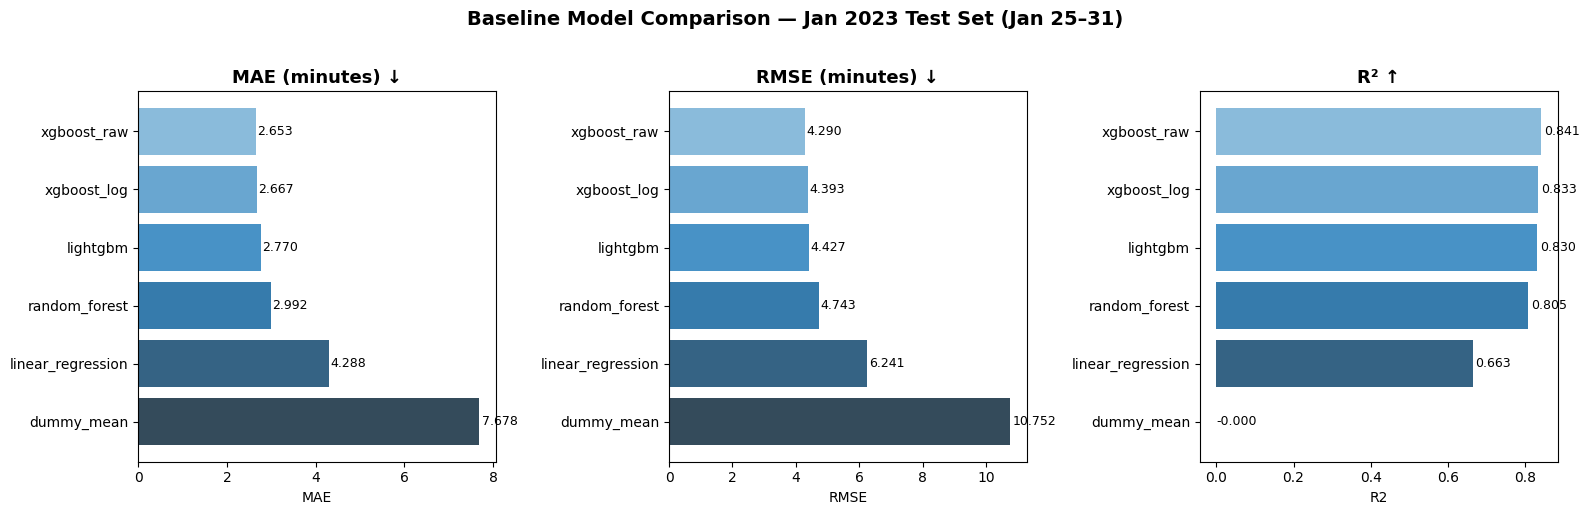

Plot saved to reports/baseline_model_comparison.png


In [34]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics_to_plot = ['mae', 'rmse', 'r2']
titles          = ['MAE (minutes) ↓', 'RMSE (minutes) ↓', 'R² ↑']
colors = sns.color_palette('Blues_d', len(test_df_results))

for ax, metric, title in zip(axes, metrics_to_plot, titles):
    order = test_df_results.sort_values(metric, ascending=(metric != 'r2'))
    bars = ax.barh(order['model'], order[metric], color=colors)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel(metric.upper())
    for bar, val in zip(bars, order[metric]):
        ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height() / 2,
                f'{val:.3f}', va='center', fontsize=9)
    ax.invert_yaxis()

plt.suptitle('Baseline Model Comparison — Jan 2023 Test Set (Jan 25–31)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'reports' / 'baseline_model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print('Plot saved to reports/baseline_model_comparison.png')

---
## Section 12 — Residual Analysis (Best Model)

Inspect the best model's error distribution to detect systematic biases.

In [35]:
best_val_metrics  = val_df_results.iloc[0]
best_test_metrics = test_df_results[test_df_results['model'] == best_model_name].iloc[0]

print(f'Best model: {best_model_name}')
print(f'\n  Val  MAE={best_val_metrics["mae"]:.3f}  RMSE={best_val_metrics["rmse"]:.3f}  R²={best_val_metrics["r2"]:.4f}')
print(f'  Test MAE={best_test_metrics["mae"]:.3f}  RMSE={best_test_metrics["rmse"]:.3f}  R²={best_test_metrics["r2"]:.4f}')
print(f'  MAE improvement over dummy (test): {best_test_metrics["mae_vs_dummy"]:.1f}%')

Best model: xgboost_raw

  Val  MAE=2.546  RMSE=4.055  R²=0.8601
  Test MAE=2.653  RMSE=4.290  R²=0.8408
  MAE improvement over dummy (test): -65.4%


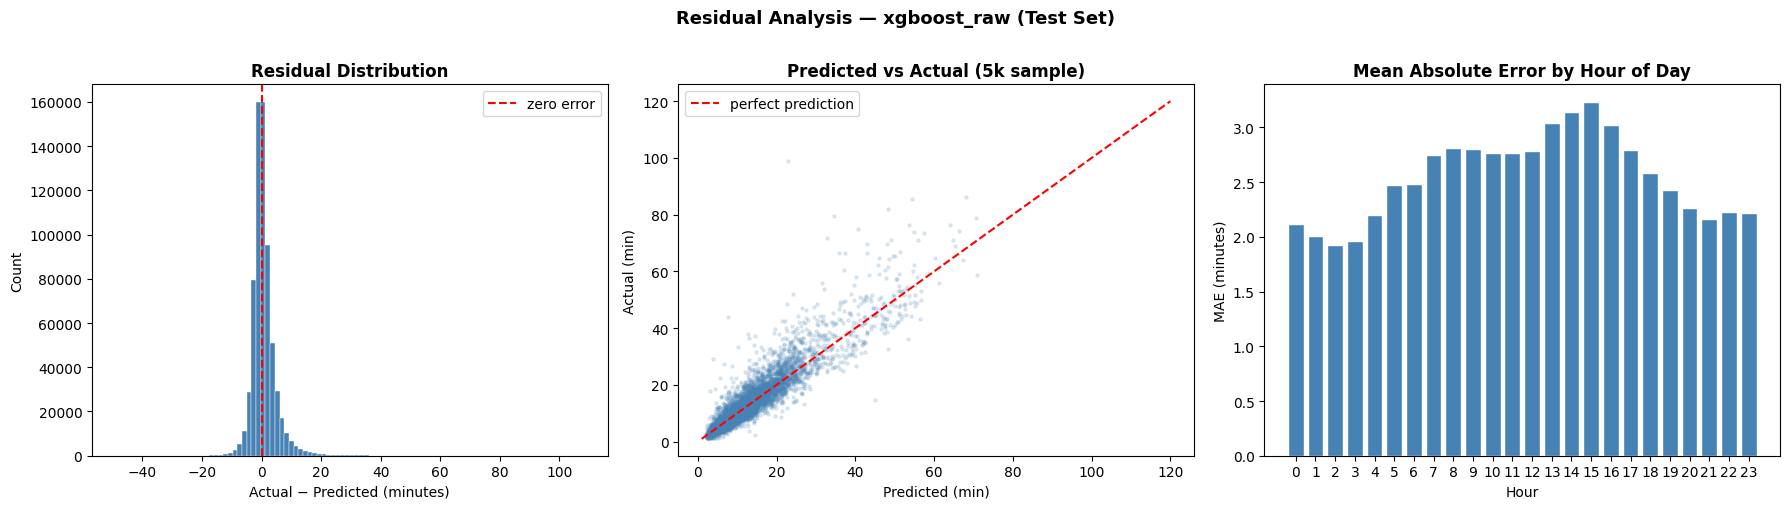

Saved to reports/residual_analysis.png


In [36]:
best_model = trained_models[best_model_name]

if best_model_name == 'xgboost_log':
    y_best_pred = np.expm1(best_model.predict(X_test))
else:
    y_best_pred = best_model.predict(X_test)

residuals = y_test.values - y_best_pred

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(residuals, bins=100, color='steelblue', edgecolor='white', linewidth=0.3)
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5, label='zero error')
axes[0].set_title('Residual Distribution', fontweight='bold')
axes[0].set_xlabel('Actual − Predicted (minutes)')
axes[0].set_ylabel('Count')
axes[0].legend()

sample_idx = np.random.RandomState(42).choice(len(y_test), size=min(5000, len(y_test)), replace=False)
axes[1].scatter(y_best_pred[sample_idx], y_test.values[sample_idx],
                alpha=0.15, s=5, color='steelblue')
lims = [1, 120]
axes[1].plot(lims, lims, 'r--', linewidth=1.5, label='perfect prediction')
axes[1].set_title('Predicted vs Actual (5k sample)', fontweight='bold')
axes[1].set_xlabel('Predicted (min)')
axes[1].set_ylabel('Actual (min)')
axes[1].legend()

test_with_preds = test_df.copy()
test_with_preds['residual'] = residuals
hourly_mae = test_with_preds.groupby('hour')['residual'].apply(lambda x: np.abs(x).mean())
axes[2].bar(hourly_mae.index, hourly_mae.values, color='steelblue', edgecolor='white')
axes[2].set_title('Mean Absolute Error by Hour of Day', fontweight='bold')
axes[2].set_xlabel('Hour')
axes[2].set_ylabel('MAE (minutes)')
axes[2].set_xticks(range(0, 24))

plt.suptitle(f'Residual Analysis — {best_model_name} (Test Set)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'reports' / 'residual_analysis.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved to reports/residual_analysis.png')

---
## Section 13 — Save Best Model & Metadata

Saves:
- `models/best_model.pkl` — serialized estimator (compatible with FastAPI serving pipeline)
- `models/model_metadata.json` — feature list, metrics, config used, target transform flag

In [37]:
MODEL_SAVE_PATH    = MODELS_DIR / 'best_model.pkl'
METADATA_SAVE_PATH = MODELS_DIR / 'model_metadata.json'

with open(MODEL_SAVE_PATH, 'wb') as f:
    pickle.dump(best_model, f)

metadata = {
    'model_name'       : best_model_name,
    'trained_on'       : f'{YEAR}-{MONTH:02d}',
    'features'         : available_features,
    'target'           : TARGET,
    'log_transform'    : best_model_name == 'xgboost_log',
    'val_cutoff_date'  : str(val_cutoff.date()),
    'test_cutoff_date' : str(test_cutoff.date()),
    'val_metrics'      : {k: round(float(v), 4) for k, v in best_val_metrics[['mae','rmse','r2']].items()},
    'test_metrics'     : {k: round(float(v), 4) for k, v in best_test_metrics[['mae','rmse','r2']].items()},
    'all_val_results'  : {
        name: {k: round(float(v), 4) for k, v in m.items()}
        for name, m in val_results.items()
    },
    'all_test_results' : {
        name: {k: round(float(v), 4) for k, v in m.items()}
        for name, m in test_results.items()
    },
    'hyperparams'      : cfg['training']['models'].get(best_model_name.replace('_raw', '').replace('_log', ''), {}),
    'random_state'     : RANDOM_STATE,
}

with open(METADATA_SAVE_PATH, 'w') as f:
    json.dump(metadata, f, indent=2)

print(f'Model saved   : {MODEL_SAVE_PATH}')
print(f'Metadata saved: {METADATA_SAVE_PATH}')
print(f'\nMetadata preview:')
print(json.dumps({k: v for k, v in metadata.items() if 'all_' not in k}, indent=2))

Model saved   : /Users/adityaboghara/Desktop/NYC End to End Project /nyc-taxi-duration-prediction-self-healing-ml/models/best_model.pkl
Metadata saved: /Users/adityaboghara/Desktop/NYC End to End Project /nyc-taxi-duration-prediction-self-healing-ml/models/model_metadata.json

Metadata preview:
{
  "model_name": "xgboost_raw",
  "trained_on": "2023-01",
  "features": [
    "trip_distance",
    "passenger_count",
    "hour",
    "dayofweek",
    "PU_borough_id",
    "DO_borough_id",
    "PULocationID",
    "DOLocationID",
    "RatecodeID",
    "is_weekend",
    "is_rush_hour",
    "is_airport_trip"
  ],
  "target": "trip_duration_min",
  "log_transform": false,
  "val_cutoff_date": "2023-01-17",
  "test_cutoff_date": "2023-01-24",
  "val_metrics": {
    "mae": 2.5457,
    "rmse": 4.0552,
    "r2": 0.8601
  },
  "test_metrics": {
    "mae": 2.6532,
    "rmse": 4.2901,
    "r2": 0.8408
  },
  "hyperparams": {
    "n_estimators": 500,
    "max_depth": 8,
    "learning_rate": 0.05,
    "sub

---
## Section 14 — Smoke Test: Load & Predict

Verify the saved model round-trips correctly — critical before wiring it into the FastAPI serving pipeline.

In [38]:
with open(MODEL_SAVE_PATH, 'rb') as f:
    loaded_model = pickle.load(f)

sample_row = X_test.iloc[[0]]
raw_pred = loaded_model.predict(sample_row)

with open(METADATA_SAVE_PATH) as f:
    loaded_meta = json.load(f)

if loaded_meta['log_transform']:
    pred_min = float(np.expm1(raw_pred[0]))
else:
    pred_min = float(raw_pred[0])

actual_min = float(y_test.iloc[0])

print('=== Smoke test: load from disk & predict ===')
print(f'Sample features : {sample_row.iloc[0].to_dict()}')
print(f'Predicted       : {pred_min:.2f} min')
print(f'Actual          : {actual_min:.2f} min')
print(f'Absolute error  : {abs(pred_min - actual_min):.2f} min')
print('\nSmoke test PASSED — model loads and predicts correctly.')

=== Smoke test: load from disk & predict ===
Sample features : {'trip_distance': 3.1, 'passenger_count': 1.0, 'hour': 0.0, 'dayofweek': 2.0, 'PU_borough_id': 3.0, 'DO_borough_id': 3.0, 'PULocationID': 114.0, 'DOLocationID': 48.0, 'RatecodeID': 1.0, 'is_weekend': 0.0, 'is_rush_hour': 0.0, 'is_airport_trip': 0.0}
Predicted       : 13.31 min
Actual          : 17.45 min
Absolute error  : 4.14 min

Smoke test PASSED — model loads and predicts correctly.


---
## Summary & Next Steps

### What was done
| Step | Detail |
|---|---|
| Data loaded | `data/processed/processed_rides_2023-01.parquet` |
| Split | Time-based — last 7 days as validation |
| Models trained | Dummy, LinearRegression, RandomForest, XGBoost (raw), XGBoost (log1p), LightGBM |
| Tracking | All runs logged to MLflow (`nyc-taxi-duration` experiment) |
| Best model saved | `models/best_model.pkl` + `models/model_metadata.json` |

### Next notebooks
- **Notebook 4** — Hyperparameter tuning (Optuna) on the best model
- **Notebook 5** — SHAP explainability
- **Notebook 6** — Drift simulation & monitoring baseline (Evidently)

### Notes for production pipeline
- `model_metadata.json` is the contract between training and serving — FastAPI reads `features` and `log_transform` from it
- `val_metrics.mae` is the reference metric for the self-healing drift threshold (`monitoring.mae_degradation_threshold_pct: 15%` in config)